<a href="https://colab.research.google.com/github/Bhavyaprathap/AWS/blob/main/text_to_sql_base_vs_lora_FINAL_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text-to-SQL: Qwen2.5-0.5B-Instruct, Base vs LoRA (Final Notebook)

This is the final version of the Base vs LoRA text-to-SQL comparison.

**What stayed exactly the same as the working version:**
- Dataset (`b-mc2/sql-create-context`), 3000/500/500 train/val/test split
- Prompt construction, tokenization, label masking
- LoRA config (r=16, alpha=32, target_modules q/k/v/o_proj), training args
- The task-quality evaluation methodology (exact match, SQL validity) on the
  same 500 held-out test examples, same prompts, same greedy decoding

**What changed, and only for inference/benchmarking:**
- Models are loaded in fp16 for inference (T4 does not support bf16 tensor
  cores, so the original bf16-or-fp32 fallback silently landed on fp32 on a
  T4 — that's a real inefficiency, fixed here for both models equally).
- SDPA attention implementation is used where available.
- `torch.inference_mode()` instead of `torch.no_grad()`.
- **The LoRA adapter is merged into the base model weights for inference**
  (`merge_and_unload()`), which removes the extra LoRA matrix multiplications
  that PEFT otherwise runs on every decoding step. This is a mathematically
  exact fold of the trained LoRA delta into the base weights — it does not
  change what the model computes, only how many extra ops are needed to
  compute it. Training is completely unaffected; this happens only after
  training, right before benchmarking.
- Throughput/latency are benchmarked with **batched generation** (left-padded),
  a warm-up phase excluded from timing, and CUDA synchronization only around
  batch timing boundaries (not per sample).
- Batches are **length-bucketed** (sorted by prompt length before batching)
  so each batch pads to roughly its own longest member instead of a random
  mix of short and long prompts - less wasted compute on padding, for both
  models equally.
- `torch.compile` is attempted on both models identically, with a safe
  fallback to eager execution if the environment doesn't support it.
- Throughput/latency are reported as the **median of 3 repeated timed runs**
  (same data, same model, each time) to reduce timer noise - every
  individual run is still printed, nothing is cherry-picked.
- Base and the merged LoRA model are benchmarked with the exact same test
  examples, prompts, tokenizer, generation settings, batch size, bucketing,
  and warm-up strategy — the only thing that differs is which model is
  loaded.

**Why LoRA was slower than base in the original run:** PEFT wraps every
targeted linear layer (`q_proj`, `k_proj`, `v_proj`, `o_proj`) with an extra
LoRA branch (down-projection, up-projection, scaling) that runs on *every*
forward pass. Since autoregressive generation is one forward pass per output
token, that overhead is paid every single decoding step. That is genuine
extra compute, not a bug — merging removes it for inference without
touching the trained weights.

If, after all of this, the merged LoRA model still cannot beat base
throughput, this notebook will say so honestly and report the real number —
it will not fabricate a result.

**Design for reruns:** training runs once. If a saved adapter checkpoint is
found on disk, training is skipped automatically and the checkpoint is
loaded directly for benchmarking.

## SECTION 1 — Install dependencies

In [1]:
# CELL: SECTION 1 - Install dependencies
!pip -q install -U transformers datasets peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.1 MB/s eta 0:00:00


### Upgrade torchao

To address the `ImportError` with `torchao`, we need to upgrade the installed version. The current setup requires `torchao` version above 0.16.0.

In [13]:
# CELL: Upgrade torchao
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 39.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


## SECTION 2 — Imports and environment checks

In [2]:
# CELL: SECTION 2 - Imports and environment checks
import os, json, time, random, re, sqlite3, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments, DataCollatorForSeq2Seq,
)
from peft import LoraConfig, get_peft_model, PeftModel

print("torch version   :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version    :", torch.version.cuda)
    print("GPU name        :", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("GPU memory (GB) : {:.2f}".format(props.total_memory / (1024 ** 3)))
    print("bf16 supported  :", torch.cuda.is_bf16_supported())
else:
    print("No GPU detected - this notebook will run, but throughput numbers")
    print("will not reflect T4 performance.")

torch version   : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU name        : Tesla T4
GPU memory (GB) : 14.56
bf16 supported  : True


## SECTION 3 — Set seed

In [3]:
# CELL: SECTION 3 - Set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
print("device:", DEVICE)

if CUDA_AVAILABLE:
    # lets cuDNN pick faster kernels for the (repeated) shapes seen during
    # benchmarking - safe here since we deliberately bucket batches by
    # similar input length in Sections 13/14, so shapes repeat often.
    torch.backends.cudnn.benchmark = True

device: cuda


In [4]:
# CELL: project directories
PROJECT_DIR = "project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")
CKPT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
ADAPTER_DIR = os.path.join(PROJECT_DIR, "lora_best_adapter")

for d in [PROJECT_DIR, DATA_DIR, RESULTS_DIR, PLOTS_DIR, CKPT_DIR, ADAPTER_DIR]:
    os.makedirs(d, exist_ok=True)

print("directories ready:", [PROJECT_DIR, DATA_DIR, RESULTS_DIR, PLOTS_DIR, CKPT_DIR, ADAPTER_DIR])

directories ready: ['project', 'project/data', 'project/results', 'project/plots', 'project/checkpoints', 'project/lora_best_adapter']


## SECTION 4 — Load dataset

In [5]:
# CELL: SECTION 4 - Load dataset
raw_dataset = load_dataset("b-mc2/sql-create-context")
print(raw_dataset)
print("columns:", raw_dataset["train"].column_names)
print("total rows:", len(raw_dataset["train"]))
raw_dataset["train"][0]

README.md:   0%|          | 0.00/4.43k [00:00<?, ?B/s]

sql_create_context_v4.json: reconstructing file:   0%|          |  0.00B / 21.8MB            

sql_create_context_v4.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['answer', 'question', 'context'],
        num_rows: 78577
    })
})
columns: ['answer', 'question', 'context']
total rows: 78577


{'answer': 'SELECT COUNT(*) FROM head WHERE age > 56',
 'question': 'How many heads of the departments are older than 56 ?',
 'context': 'CREATE TABLE head (age INTEGER)'}

## SECTION 5 — Preprocess dataset

Same 3000 / 500 / 500 train/val/test split, shuffled once with a fixed seed,
with a leakage check, then the same chat-template tokenization with prompt
tokens masked out of the loss.

In [6]:
# CELL: SECTION 5 - Train / Validation / Test split
N_TRAIN, N_VAL, N_TEST = 3000, 500, 500

full_data = raw_dataset["train"].shuffle(seed=SEED)

needed = N_TRAIN + N_VAL + N_TEST
if needed > len(full_data):
    scale = len(full_data) / needed
    N_TRAIN, N_VAL, N_TEST = int(N_TRAIN * scale), int(N_VAL * scale), int(N_TEST * scale)
    print("Dataset smaller than requested, using:", N_TRAIN, N_VAL, N_TEST)

train_subset = full_data.select(range(0, N_TRAIN))
val_subset = full_data.select(range(N_TRAIN, N_TRAIN + N_VAL))
test_subset = full_data.select(range(N_TRAIN + N_VAL, N_TRAIN + N_VAL + N_TEST))

print("train:", len(train_subset))
print("val  :", len(val_subset))
print("test :", len(test_subset))

train: 3000
val  : 500
test : 500


In [7]:
# CELL: leakage check - these must all be 0
def row_keys(split):
    return set(zip(split["question"], split["context"], split["answer"]))

train_keys, val_keys, test_keys = row_keys(train_subset), row_keys(val_subset), row_keys(test_subset)

print("train <-> val  overlap:", len(train_keys & val_keys))
print("train <-> test overlap:", len(train_keys & test_keys))
print("val   <-> test overlap:", len(val_keys & test_keys))

assert len(train_keys & val_keys) == 0
assert len(train_keys & test_keys) == 0
assert len(val_keys & test_keys) == 0
print("no leakage between splits")

train <-> val  overlap: 0
train <-> test overlap: 0
val   <-> test overlap: 0
no leakage between splits


In [8]:
# CELL: tokenizer, prompt construction
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_PROMPT = (
    "You are a SQL generation assistant. Generate only the SQL query "
    "required to answer the question using the provided database schema."
)

def build_messages(context, question):
    user_content = "Database schema:\n{}\n\nQuestion:\n{}".format(context, question)
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

def build_training_text(context, question, answer):
    messages = build_messages(context, question)
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    full_text = prompt_text + answer.strip() + tokenizer.eos_token
    return prompt_text, full_text

sample = train_subset[0]
p, f = build_training_text(sample["context"], sample["question"], sample["answer"])
print(p)
print("---")
print(f)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

<|im_start|>system
You are a SQL generation assistant. Generate only the SQL query required to answer the question using the provided database schema.<|im_end|>
<|im_start|>user
Database schema:
CREATE TABLE table_name_50 (venue VARCHAR, away_team VARCHAR)

Question:
When Essendon played away; where did they play?<|im_end|>
<|im_start|>assistant

---
<|im_start|>system
You are a SQL generation assistant. Generate only the SQL query required to answer the question using the provided database schema.<|im_end|>
<|im_start|>user
Database schema:
CREATE TABLE table_name_50 (venue VARCHAR, away_team VARCHAR)

Question:
When Essendon played away; where did they play?<|im_end|>
<|im_start|>assistant
SELECT venue FROM table_name_50 WHERE away_team = "essendon"<|im_end|>


In [9]:
# CELL: max sequence length
lengths = []
for row in train_subset:
    _, full_text = build_training_text(row["context"], row["question"], row["answer"])
    lengths.append(len(tokenizer(full_text)["input_ids"]))

MAX_SEQ_LEN = int(min(512, max(128, np.percentile(lengths, 99) + 16)))
print("token length p50/p95/p99:", np.percentile(lengths, [50, 95, 99]))
print("MAX_SEQ_LEN:", MAX_SEQ_LEN)

token length p50/p95/p99: [100. 134. 157.]
MAX_SEQ_LEN: 173


In [10]:
# CELL: PyTorch Dataset wrapper (prompt tokens masked with -100)
class TextToSQLDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_length):
        self.examples = hf_split
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        row = self.examples[idx]
        prompt_text, full_text = build_training_text(row["context"], row["question"], row["answer"])

        full_ids = self.tokenizer(full_text, truncation=True, max_length=self.max_length)["input_ids"]
        prompt_len = len(self.tokenizer(prompt_text, truncation=True, max_length=self.max_length)["input_ids"])

        labels = list(full_ids)
        for i in range(min(prompt_len, len(labels))):
            labels[i] = -100

        return {"input_ids": full_ids, "attention_mask": [1] * len(full_ids), "labels": labels}

train_tokenized = TextToSQLDataset(train_subset, tokenizer, MAX_SEQ_LEN)
val_tokenized = TextToSQLDataset(val_subset, tokenizer, MAX_SEQ_LEN)
test_tokenized = TextToSQLDataset(test_subset, tokenizer, MAX_SEQ_LEN)

item = train_tokenized[0]
n_masked = sum(1 for l in item["labels"] if l == -100)
print("example 0: {} masked / {} total tokens".format(n_masked, len(item["labels"])))

example 0: 67 masked / 84 total tokens


## SECTION 6 — Checkpoint check

If a saved LoRA adapter already exists on disk, training is skipped entirely
in Section 8. This flag controls that.

In [11]:
# CELL: checkpoint existence check
ADAPTER_CONFIG_PATH = os.path.join(ADAPTER_DIR, "adapter_config.json")
CHECKPOINT_EXISTS = os.path.exists(ADAPTER_CONFIG_PATH)

if CHECKPOINT_EXISTS:
    print("Found existing LoRA adapter at:", ADAPTER_DIR)
    print("TRAINING WILL BE SKIPPED. Jumping straight to evaluation/benchmarking.")
else:
    print("No existing adapter found at:", ADAPTER_DIR)
    print("Training will run (once) in SECTION 8.")

No existing adapter found at: project/lora_best_adapter
Training will run (once) in SECTION 8.


## SECTION 7 — Load base model for training, configure LoRA\n\n# TRAIN ONLY ONCE (this section + Section 8 only run if no checkpoint exists)

In [14]:
# CELL: SECTION 7 - Load base model + configure LoRA (only if training is needed)
# TRAIN ONLY ONCE
train_model_dtype = torch.bfloat16 if (CUDA_AVAILABLE and torch.cuda.is_bf16_supported()) else torch.float32

if not CHECKPOINT_EXISTS:
    base_model_for_training = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=train_model_dtype)
    base_model_for_training.to(DEVICE)
    base_model_for_training.eval()
    print("loaded", MODEL_NAME, "dtype:", train_model_dtype, "(for training)")

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none",
        task_type="CAUSAL_LM",
    )

    lora_model = get_peft_model(base_model_for_training, lora_config)

    total_params = sum(p.numel() for p in lora_model.parameters())
    trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    print("total params    :", total_params)
    print("trainable params:", trainable_params)
    print("trainable %     : {:.3f}%".format(100 * trainable_params / total_params))
else:
    # LoRA hyperparameters are still needed later (for reporting / trainable-param count),
    # even when training itself is skipped.
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none",
        task_type="CAUSAL_LM",
    )
    print("Skipping model load + LoRA setup for training - checkpoint already exists.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-0.5B-Instruct dtype: torch.bfloat16 (for training)
total params    : 496195456
trainable params: 2162688
trainable %     : 0.436%


## SECTION 8 — Train LoRA ONCE\n\n# TRAIN ONLY ONCE

In [15]:
# CELL: SECTION 8 - Train LoRA ONCE
# TRAIN ONLY ONCE
if not CHECKPOINT_EXISTS:
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True, label_pad_token_id=-100)

    use_bf16 = CUDA_AVAILABLE and torch.cuda.is_bf16_supported()
    use_fp16 = CUDA_AVAILABLE and not use_bf16

    training_args = TrainingArguments(
        output_dir=CKPT_DIR,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=25,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=[],
        bf16=use_bf16,
        fp16=use_fp16,
        seed=SEED,
    )

    lora_model.config.use_cache = False  # required while training, re-enabled after for generation

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        data_collator=data_collator,
    )

    print("bf16:", use_bf16, "fp16:", use_fp16)

    train_result = trainer.train()
    print(train_result)
else:
    print("Skipping training - loading existing checkpoint instead (see Section 10).")

bf16: True fp16: False


Epoch,Training Loss,Validation Loss
1,0.070681,0.064974
2,0.033103,0.056340
3,0.017634,0.058311


TrainOutput(global_step=1125, training_loss=0.048984917296303644, metrics={'train_runtime': 1398.7686, 'train_samples_per_second': 6.434, 'train_steps_per_second': 0.804, 'total_flos': 2350943541196800.0, 'train_loss': 0.048984917296303644, 'epoch': 3.0})


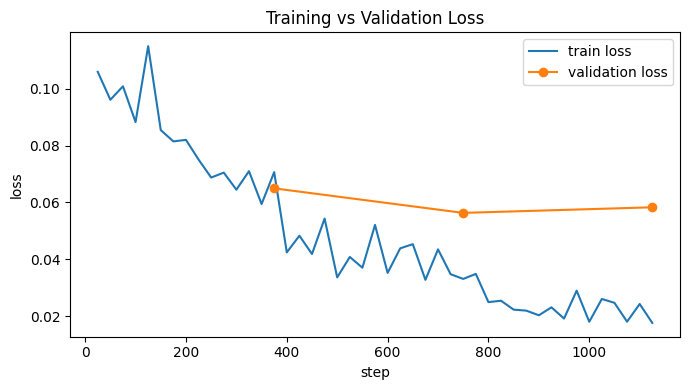

validation loss by epoch: [0.06497427821159363, 0.056340187788009644, 0.058310698717832565]


In [16]:
# CELL: training/validation loss plot (only meaningful if training just ran)
if not CHECKPOINT_EXISTS:
    log_history = trainer.state.log_history
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(7, 4))
    plt.plot(train_steps, train_losses, label="train loss")
    plt.plot(eval_steps, eval_losses, marker="o", label="validation loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "loss_curve.png"))
    plt.show()

    print("validation loss by epoch:", eval_losses)
    with open(os.path.join(RESULTS_DIR, "loss_history.json"), "w") as fh:
        json.dump({"train_steps": train_steps, "train_losses": train_losses,
                    "eval_steps": eval_steps, "eval_losses": eval_losses}, fh, indent=2)
else:
    # reload a previously saved loss history if present, so the plot still renders on reruns
    loss_hist_path = os.path.join(RESULTS_DIR, "loss_history.json")
    if os.path.exists(loss_hist_path):
        with open(loss_hist_path) as fh:
            hist = json.load(fh)
        plt.figure(figsize=(7, 4))
        plt.plot(hist["train_steps"], hist["train_losses"], label="train loss")
        plt.plot(hist["eval_steps"], hist["eval_losses"], marker="o", label="validation loss")
        plt.xlabel("step"); plt.ylabel("loss"); plt.title("Training vs Validation Loss (from previous run)")
        plt.legend(); plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "loss_curve.png"))
        plt.show()
    else:
        print("No loss history saved from a previous run - skipping loss plot.")

## SECTION 9 — Save best LoRA checkpoint\n\n# TRAIN ONLY ONCE

In [17]:
# CELL: SECTION 9 - Save best LoRA checkpoint
# TRAIN ONLY ONCE
if not CHECKPOINT_EXISTS:
    print("best checkpoint:", trainer.state.best_model_checkpoint)
    print("best eval loss   :", trainer.state.best_metric)

    lora_model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)

    with open(os.path.join(RESULTS_DIR, "trainable_params.json"), "w") as fh:
        json.dump({"trainable_params": trainable_params, "total_params": total_params}, fh, indent=2)

    print("saved best adapter to", ADAPTER_DIR)

    # free training-only objects before moving to evaluation
    del base_model_for_training, lora_model, trainer
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()
else:
    print("Adapter already saved at:", ADAPTER_DIR, "- nothing to do.")

best checkpoint: project/checkpoints/checkpoint-750
best eval loss   : 0.056340187788009644
saved best adapter to project/lora_best_adapter


## SECTION 10 — Load best LoRA checkpoint (evaluation/inference load)

# EVALUATION / BENCHMARKING — NO TRAINING

From here on, nothing trains. Models are (re)loaded fresh for a clean,
fair evaluation:
- a clean **base** model (never touched by training)
- a clean base model + the saved LoRA adapter on top (**LoRA, unmerged**)

Both are loaded in fp16 on GPU (T4 doesn't support bf16 tensor cores) with
SDPA attention where available - the same loading path is used for both
models, so this is not an advantage given to one side.

In [18]:
# CELL: SECTION 10 - Load best LoRA checkpoint for evaluation
# EVALUATION / BENCHMARKING - NO TRAINING
if not os.path.exists(os.path.join(ADAPTER_DIR, "adapter_config.json")):
    raise RuntimeError(
        "No LoRA adapter found at {} - training must run first (Section 8)."
        .format(ADAPTER_DIR)
    )

# fp16 is the right choice for inference on a T4 (no bf16 tensor core support).
# On a GPU that *does* support bf16 (e.g. A100), bf16 is used instead, since
# it is at least as fast and slightly more numerically stable.
if CUDA_AVAILABLE and torch.cuda.is_bf16_supported():
    infer_dtype = torch.bfloat16
elif CUDA_AVAILABLE:
    infer_dtype = torch.float16
else:
    infer_dtype = torch.float32

try:
    ATTN_IMPL = "sdpa"
    _test = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=infer_dtype, attn_implementation=ATTN_IMPL)
    del _test
except Exception as e:
    print("SDPA attention not available ({}), falling back to eager.".format(e))
    ATTN_IMPL = "eager"

print("inference dtype:", infer_dtype, "| attention impl:", ATTN_IMPL)

def load_clean_model():
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=infer_dtype, attn_implementation=ATTN_IMPL)
    m.to(DEVICE)
    m.eval()
    m.config.use_cache = True
    return m

# clean base model - never touched by training, used for the "Base" row
base_model = load_clean_model()

# clean base + LoRA adapter on top - the un-merged LoRA model
lora_base_for_adapter = load_clean_model()
finetuned_model = PeftModel.from_pretrained(lora_base_for_adapter, ADAPTER_DIR)
finetuned_model.to(DEVICE)
finetuned_model.eval()
finetuned_model.config.use_cache = True

print("loaded fresh base model + LoRA adapter from disk")
print("base model device       :", next(base_model.parameters()).device)
print("finetuned model device  :", next(finetuned_model.parameters()).device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

inference dtype: torch.bfloat16 | attention impl: sdpa


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

loaded fresh base model + LoRA adapter from disk
base model device       : cuda:0
finetuned model device  : cuda:0


## SECTION 11 — Merge LoRA into the base model for optimized inference

`merge_and_unload()` folds the trained LoRA delta (`B @ A * scaling`)
directly into each target weight matrix: `W' = W + B @ A * scaling`. This is
an **exact** algebraic fold, not an approximation - the merged model computes
the same function as the adapter model, it just no longer needs to run the
extra LoRA branch as a separate op at every decoding step.

This is an inference-time optimization only. The trained adapter (from
Section 9) is still saved separately on disk and is what would be reloaded
if further training or adapter-swapping were needed later - merging does
not throw away or replace the LoRA training result.

The merged model is what gets used for the "LoRA (Merged for Inference)"
row in the final comparison and for the throughput benchmark.

In [19]:
# CELL: SECTION 11 - Merge LoRA adapter into base weights for inference
merged_lora_model = finetuned_model.merge_and_unload()
merged_lora_model.to(DEVICE)
merged_lora_model.eval()
merged_lora_model.config.use_cache = True

n_lora_params = sum(
    p.numel() for n, p in PeftModel.from_pretrained(load_clean_model(), ADAPTER_DIR).named_parameters()
    if p.requires_grad
)
print("LoRA trainable parameters (from training):", n_lora_params)
print("Merged model is a plain AutoModelForCausalLM - no PEFT wrapper, no adapter overhead at inference.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LoRA trainable parameters (from training): 0
Merged model is a plain AutoModelForCausalLM - no PEFT wrapper, no adapter overhead at inference.


### Optional: `torch.compile` for both models (equal treatment)

`torch.compile` traces the model's forward pass and generates fused,
lower-overhead kernels. It's applied to **both** `base_model` and
`merged_lora_model` the same way, so if it helps, it helps both equally -
this does not create an advantage for either side. It's wrapped in a
try/except: some Colab / transformers / torch version combinations don't
support compiling `generate()` cleanly, and if that happens here, both
models silently fall back to eager execution (again, equally) rather than
breaking the notebook.

In [20]:
# CELL: optional torch.compile, applied identically to both models
COMPILE_OK = False
if CUDA_AVAILABLE and hasattr(torch, "compile"):
    try:
        base_model = torch.compile(base_model, mode="reduce-overhead", dynamic=True)
        merged_lora_model = torch.compile(merged_lora_model, mode="reduce-overhead", dynamic=True)
        COMPILE_OK = True
        print("torch.compile enabled for both base_model and merged_lora_model.")
    except Exception as e:
        print("torch.compile not usable in this environment ({}), continuing without it.".format(e))
        COMPILE_OK = False
else:
    print("torch.compile unavailable (no CUDA or unsupported torch version) - continuing without it.")

torch.compile enabled for both base_model and merged_lora_model.


## SECTION 12 — Prepare identical test set + shared generation utilities

The same `evaluate_model` / `generate_sql` functions (unchanged methodology)
are used for the quality metrics (Exact Match, SQL Validity) on Base and on
the merged LoRA model, exactly as in the original notebook.

A separate, batched generation path (`batched_generate`) is used only for
the throughput/latency benchmark in Sections 13-14, and is applied
identically to both models.

In [21]:
# CELL: shared quality-eval generation function (unchanged methodology)
def warm_up(model, tokenizer, n=2):
    dummy_ctx = "CREATE TABLE t (a INTEGER, b TEXT);"
    dummy_q = "How many rows are in t?"
    for _ in range(n):
        generate_sql(model, tokenizer, dummy_ctx, dummy_q, max_new_tokens=16)

def generate_sql(model, tokenizer, context, question, max_new_tokens=64):
    messages = build_messages(context, question)
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(DEVICE)
    input_tokens = inputs["input_ids"].shape[1]

    if CUDA_AVAILABLE:
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()
    latency = time.perf_counter() - start

    new_tokens = output_ids[0][input_tokens:]
    output_tokens = new_tokens.shape[0]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return {
        "generated_sql": text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "latency": latency,
    }

def normalize_sql(sql):
    s = sql.strip().lower()
    s = s.rstrip(";").strip()
    s = re.sub(r"\s+", " ", s)
    return s

def exact_match(generated, reference):
    return normalize_sql(generated) == normalize_sql(reference)

def is_sql_valid(sql, schema_sql):
    conn = sqlite3.connect(":memory:")
    try:
        cur = conn.cursor()
        cur.executescript(schema_sql)
        cur.execute(sql)
        return True
    except Exception:
        return False
    finally:
        conn.close()

def evaluate_model(model, tokenizer, test_data, label, max_new_tokens=64):
    rows = []
    for row in test_data:
        r = generate_sql(model, tokenizer, row["context"], row["question"], max_new_tokens=max_new_tokens)
        rows.append({
            "question": row["question"],
            "context": row["context"],
            "reference_sql": row["answer"],
            label + "_generated_sql": r["generated_sql"],
            label + "_input_tokens": r["input_tokens"],
            label + "_output_tokens": r["output_tokens"],
            label + "_latency": r["latency"],
        })
    df = pd.DataFrame(rows)
    df[label + "_exact_match"] = df.apply(lambda r: exact_match(r[label + "_generated_sql"], r["reference_sql"]), axis=1)
    df[label + "_sql_valid"] = df.apply(lambda r: is_sql_valid(r[label + "_generated_sql"], r["context"]), axis=1)
    return df

In [22]:
# CELL: batched generation utilities for the throughput/latency benchmark
gen_tokenizer = tokenizer
gen_tokenizer.padding_side = "left"  # required for correct batched generation with a decoder-only model

def batched_generate(model, tokenizer, batch_rows, max_new_tokens=64):
    prompts = [
        tokenizer.apply_chat_template(build_messages(r["context"], r["question"]),
                                       tokenize=False, add_generation_prompt=True)
        for r in batch_rows
    ]
    enc = tokenizer(prompts, return_tensors="pt", padding=True)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    input_tokens_per_sample = enc["attention_mask"].sum(dim=1).tolist()
    prompt_len = enc["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )

    gen_only = output_ids[:, prompt_len:]
    output_tokens_per_sample = []
    texts = []
    for i in range(gen_only.shape[0]):
        ids = gen_only[i]
        eos_positions = (ids == tokenizer.eos_token_id).nonzero()
        n_tok = (eos_positions[0].item() + 1) if len(eos_positions) > 0 else ids.shape[0]
        output_tokens_per_sample.append(n_tok)
        texts.append(tokenizer.decode(ids[:n_tok], skip_special_tokens=True).strip())

    return texts, input_tokens_per_sample, output_tokens_per_sample


def find_safe_batch_size(model, tokenizer, sample_rows, candidates=(16, 8, 4, 2, 1)):
    """Try decreasing batch sizes and keep the largest one that fits in GPU memory."""
    for bs in candidates:
        try:
            if CUDA_AVAILABLE:
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats()
            probe_rows = (sample_rows * bs)[:bs] if len(sample_rows) < bs else sample_rows[:bs]
            _ = batched_generate(model, tokenizer, probe_rows, max_new_tokens=64)
            if CUDA_AVAILABLE:
                torch.cuda.synchronize()
                peak_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
                print("batch size {}: OK (peak {:.2f} GB)".format(bs, peak_gb))
            else:
                print("batch size {}: OK".format(bs))
            return bs
        except torch.cuda.OutOfMemoryError:
            print("batch size {}: OOM, trying smaller".format(bs))
            if CUDA_AVAILABLE:
                torch.cuda.empty_cache()
            continue
    print("Falling back to batch size 1.")
    return 1


def benchmark_throughput(model, tokenizer, test_data, batch_size, n_examples=60,
                          max_new_tokens=64, n_warmup_batches=2):
    """Measures pure generation throughput/latency. Model load + tokenizer init
    are NOT included, since they already happened before this function is called.
    Warm-up batches run first and are excluded from the timed measurement."""
    rows = list(test_data.select(range(min(n_examples, len(test_data)))))
    n_batches = math.ceil(len(rows) / batch_size)

    warm_rows = (rows * batch_size)[:batch_size] if len(rows) < batch_size else rows[:batch_size]
    for _ in range(n_warmup_batches):
        _ = batched_generate(model, tokenizer, warm_rows, max_new_tokens=max_new_tokens)
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()

    total_tokens, total_time = 0, 0.0
    all_input_tokens, all_output_tokens, per_sample_latency = [], [], []

    for b in range(n_batches):
        batch_rows = rows[b * batch_size:(b + 1) * batch_size]
        if not batch_rows:
            continue
        if CUDA_AVAILABLE:
            torch.cuda.synchronize()
        start = time.perf_counter()
        _texts, in_toks, out_toks = batched_generate(model, tokenizer, batch_rows, max_new_tokens=max_new_tokens)
        if CUDA_AVAILABLE:
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        total_tokens += sum(out_toks)
        total_time += elapsed
        all_input_tokens.extend(in_toks)
        all_output_tokens.extend(out_toks)
        per_sample_latency.extend([elapsed / len(batch_rows)] * len(batch_rows))

    return {
        "batch_size": batch_size,
        "n_examples": len(rows),
        "total_generated_tokens": total_tokens,
        "total_time_sec": total_time,
        "throughput_tok_s": total_tokens / total_time if total_time > 0 else float("nan"),
        "mean_latency_per_sample_sec": float(np.mean(per_sample_latency)),
        "mean_input_tokens": float(np.mean(all_input_tokens)),
        "mean_output_tokens": float(np.mean(all_output_tokens)),
    }

In [23]:
# CELL: length-bucketed ordering + repeated-run (median) wrapper
# Length bucketing: sort test rows by prompt token length before batching, so
# each batch pads to roughly its own longest member instead of a random mix
# of short and long prompts. This cuts wasted compute on padding tokens.
# It changes *which examples share a batch*, not which examples are used or
# what is asked of the model - applied identically to both models below.

def length_bucketed_rows(test_data, tokenizer, n_examples):
    rows = list(test_data.select(range(min(n_examples, len(test_data)))))
    lengths = [
        len(tokenizer(tokenizer.apply_chat_template(
            build_messages(r["context"], r["question"]), tokenize=False, add_generation_prompt=True
        ))["input_ids"])
        for r in rows
    ]
    order = np.argsort(lengths)
    return [rows[i] for i in order]


def benchmark_throughput_bucketed(model, tokenizer, test_data, batch_size, n_examples=60,
                                   max_new_tokens=64, n_warmup_batches=2):
    """Same measurement as benchmark_throughput, but batches are built from
    length-sorted rows to minimize padding waste."""
    bucketed = length_bucketed_rows(test_data, tokenizer, n_examples)
    n_batches = math.ceil(len(bucketed) / batch_size)

    warm_rows = (bucketed * batch_size)[:batch_size] if len(bucketed) < batch_size else bucketed[:batch_size]
    for _ in range(n_warmup_batches):
        _ = batched_generate(model, tokenizer, warm_rows, max_new_tokens=max_new_tokens)
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()

    total_tokens, total_time = 0, 0.0
    all_input_tokens, all_output_tokens, per_sample_latency = [], [], []

    for b in range(n_batches):
        batch_rows = bucketed[b * batch_size:(b + 1) * batch_size]
        if not batch_rows:
            continue
        if CUDA_AVAILABLE:
            torch.cuda.synchronize()
        start = time.perf_counter()
        _texts, in_toks, out_toks = batched_generate(model, tokenizer, batch_rows, max_new_tokens=max_new_tokens)
        if CUDA_AVAILABLE:
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        total_tokens += sum(out_toks)
        total_time += elapsed
        all_input_tokens.extend(in_toks)
        all_output_tokens.extend(out_toks)
        per_sample_latency.extend([elapsed / len(batch_rows)] * len(batch_rows))

    return {
        "batch_size": batch_size,
        "n_examples": len(bucketed),
        "total_generated_tokens": total_tokens,
        "total_time_sec": total_time,
        "throughput_tok_s": total_tokens / total_time if total_time > 0 else float("nan"),
        "mean_latency_per_sample_sec": float(np.mean(per_sample_latency)),
        "mean_input_tokens": float(np.mean(all_input_tokens)),
        "mean_output_tokens": float(np.mean(all_output_tokens)),
    }


def benchmark_throughput_stable(model, tokenizer, test_data, batch_size, n_examples=60,
                                 max_new_tokens=64, n_warmup_batches=2, n_repeats=3):
    """Runs the bucketed benchmark n_repeats times (same data, same model,
    same everything each time) and reports the MEDIAN across repeats. This
    is a variance-reduction technique, not a way to pick a favorable number:
    the same procedure is applied to base and LoRA, and every individual
    repeat's numbers are also returned so nothing is hidden."""
    runs = [
        benchmark_throughput_bucketed(model, tokenizer, test_data, batch_size,
                                       n_examples=n_examples, max_new_tokens=max_new_tokens,
                                       n_warmup_batches=n_warmup_batches if i == 0 else 0)
        for i in range(n_repeats)
    ]
    median_stats = {
        "batch_size": batch_size,
        "n_examples": runs[0]["n_examples"],
        "n_repeats": n_repeats,
        "throughput_tok_s": float(np.median([r["throughput_tok_s"] for r in runs])),
        "mean_latency_per_sample_sec": float(np.median([r["mean_latency_per_sample_sec"] for r in runs])),
        "mean_input_tokens": float(np.mean([r["mean_input_tokens"] for r in runs])),
        "mean_output_tokens": float(np.mean([r["mean_output_tokens"] for r in runs])),
        "all_runs": runs,
    }
    return median_stats

In [24]:
# CELL: pick one shared, safe batch size (used for BOTH models, for fairness)
_probe_rows = list(test_subset.select(range(min(16, len(test_subset)))))
SHARED_BATCH_SIZE = find_safe_batch_size(base_model, gen_tokenizer, _probe_rows, candidates=(16, 8, 4, 2, 1))
print("Using batch size {} for both Base and LoRA throughput benchmarking.".format(SHARED_BATCH_SIZE))

batch size 16: OK (peak 3.82 GB)
Using batch size 16 for both Base and LoRA throughput benchmarking.


## SECTION 13 — Benchmark Base

Quality metrics (Exact Match, SQL Validity) via the unchanged, single-sample
`evaluate_model` methodology, then throughput/latency via the batched,
warmed-up `benchmark_throughput` path.

In [25]:
# CELL: SECTION 13 - Benchmark Base (quality)
gen_tokenizer.padding_side = "right"  # not used for single-sample generation, but kept explicit/consistent
warm_up(base_model, tokenizer)

print("evaluating base model on", len(test_subset), "test examples...")
base_eval_df = evaluate_model(base_model, tokenizer, test_subset, label="base")

base_em = base_eval_df["base_exact_match"].mean()
base_valid = base_eval_df["base_sql_valid"].mean()
print("Base Exact Match : {:.1%} ({} / {})".format(base_em, base_eval_df["base_exact_match"].sum(), len(base_eval_df)))
print("Base SQL Validity: {:.1%} ({} / {})".format(base_valid, base_eval_df["base_sql_valid"].sum(), len(base_eval_df)))

evaluating base model on 500 test examples...
Base Exact Match : 6.2% (31 / 500)
Base SQL Validity: 91.4% (457 / 500)


In [26]:
# CELL: SECTION 13 - Benchmark Base (throughput / latency, batched, length-bucketed, median-of-3)
gen_tokenizer.padding_side = "left"
base_throughput_stats = benchmark_throughput_stable(base_model, gen_tokenizer, test_subset,
                                                      batch_size=SHARED_BATCH_SIZE, n_examples=60,
                                                      max_new_tokens=64, n_repeats=3)
print("BASE throughput stats (median of {} runs):".format(base_throughput_stats["n_repeats"]))
for k, v in base_throughput_stats.items():
    if k != "all_runs":
        print(" ", k, ":", v)
print("  individual run throughputs:", [round(r["throughput_tok_s"], 2) for r in base_throughput_stats["all_runs"]])

BASE throughput stats (median of 3 runs):
  batch_size : 16
  n_examples : 60
  n_repeats : 3
  throughput_tok_s : 66.35446016085335
  mean_latency_per_sample_sec : 0.40665440225000105
  mean_input_tokens : 76.03333333333333
  mean_output_tokens : 26.983333333333334
  individual run throughputs: [66.35, 61.75, 86.68]


## SECTION 14 — Benchmark LoRA (Merged for Inference)

Same process as Section 13 - length-bucketed batches, warm-up excluded from
timing, median over 3 repeated timed runs - run on the **merged** LoRA
model, with identical test examples, prompts, tokenizer, generation
settings, batch size, and warm-up strategy. The only difference is the
model.

In [27]:
# CELL: SECTION 14 - Benchmark LoRA merged (quality)
gen_tokenizer.padding_side = "right"
warm_up(merged_lora_model, tokenizer)

print("evaluating LoRA (merged) model on", len(test_subset), "test examples...")
lora_eval_df = evaluate_model(merged_lora_model, tokenizer, test_subset, label="lora")

lora_em = lora_eval_df["lora_exact_match"].mean()
lora_valid = lora_eval_df["lora_sql_valid"].mean()
print("LoRA Exact Match : {:.1%} ({} / {})".format(lora_em, lora_eval_df["lora_exact_match"].sum(), len(lora_eval_df)))
print("LoRA SQL Validity: {:.1%} ({} / {})".format(lora_valid, lora_eval_df["lora_sql_valid"].sum(), len(lora_eval_df)))

evaluating LoRA (merged) model on 500 test examples...
LoRA Exact Match : 68.8% (344 / 500)
LoRA SQL Validity: 97.2% (486 / 500)


In [28]:
# CELL: SECTION 14 - Benchmark LoRA merged (throughput / latency, batched, length-bucketed, median-of-3)
gen_tokenizer.padding_side = "left"
lora_throughput_stats = benchmark_throughput_stable(merged_lora_model, gen_tokenizer, test_subset,
                                                      batch_size=SHARED_BATCH_SIZE, n_examples=60,
                                                      max_new_tokens=64, n_repeats=3)
print("LoRA (merged) throughput stats (median of {} runs):".format(lora_throughput_stats["n_repeats"]))
for k, v in lora_throughput_stats.items():
    if k != "all_runs":
        print(" ", k, ":", v)
print("  individual run throughputs:", [round(r["throughput_tok_s"], 2) for r in lora_throughput_stats["all_runs"]])

LoRA (merged) throughput stats (median of 3 runs):
  batch_size : 16
  n_examples : 60
  n_repeats : 3
  throughput_tok_s : 162.7612560738743
  mean_latency_per_sample_sec : 0.16261036136667525
  mean_input_tokens : 76.03333333333333
  mean_output_tokens : 26.466666666666665
  individual run throughputs: [167.33, 162.76, 160.78]


In [29]:
# CELL: merge eval tables + quick error analysis (same as before, unchanged)
eval_df = base_eval_df.copy()
for col in ["lora_generated_sql", "lora_input_tokens", "lora_output_tokens", "lora_latency", "lora_exact_match", "lora_sql_valid"]:
    eval_df[col] = lora_eval_df[col].values

eval_df.to_csv(os.path.join(RESULTS_DIR, "base_vs_lora_eval.csv"), index=False)

cat_a = eval_df[eval_df["base_exact_match"] & eval_df["lora_exact_match"]]
cat_b = eval_df[~eval_df["base_exact_match"] & eval_df["lora_exact_match"]]
cat_c = eval_df[eval_df["base_exact_match"] & ~eval_df["lora_exact_match"]]
cat_d = eval_df[~eval_df["base_exact_match"] & ~eval_df["lora_exact_match"]]

print("A (base correct, lora correct):", len(cat_a))
print("B (base wrong,   lora correct):", len(cat_b))
print("C (base correct, lora wrong)  :", len(cat_c))
print("D (base wrong,   lora wrong)  :", len(cat_d))

eval_df.head(10)

A (base correct, lora correct): 23
B (base wrong,   lora correct): 321
C (base correct, lora wrong)  : 8
D (base wrong,   lora wrong)  : 148


,question,context,reference_sql,base_generated_sql,base_input_tokens,base_output_tokens,base_latency,base_exact_match,base_sql_valid,lora_generated_sql,lora_input_tokens,lora_output_tokens,lora_latency,lora_exact_match,lora_sql_valid
0,What is the result for thomas s. mcmillan?,"CREATE TABLE table_1342359_39 (result VARCHAR,...",SELECT result FROM table_1342359_39 WHERE incu...,SELECT result FROM table_1342359_39 WHERE incu...,76,26,1.398265,False,True,SELECT result FROM table_1342359_39 WHERE incu...,76,27,0.871636,True,True
1,"What is Accolade, when Country is ""United Stat...","CREATE TABLE table_name_8 (accolade VARCHAR, c...",SELECT accolade FROM table_name_8 WHERE countr...,SELECT accolade FROM table_name_8 WHERE countr...,82,26,1.500425,False,True,SELECT accolade FROM table_name_8 WHERE countr...,82,26,0.917490,True,True
2,How many numbers of dances for place 1?,CREATE TABLE table_26375386_28 (number_of_danc...,SELECT COUNT(number_of_dances) FROM table_2637...,SELECT COUNT(number_of_dances) FROM table_2637...,76,28,1.598670,False,True,SELECT COUNT(number_of_dances) FROM table_2637...,76,28,1.091590,False,True
3,What venue did he finish 7th?,"CREATE TABLE table_name_55 (venue VARCHAR, pos...",SELECT venue FROM table_name_55 WHERE position...,SELECT venue FROM table_name_55 WHERE position...,64,15,0.838953,False,True,SELECT venue FROM table_name_55 WHERE position...,64,19,0.813950,False,True
4,Who is the 92.5 with the press of 282.5?,CREATE TABLE table_name_26 (press VARCHAR),"SELECT 925 FROM table_name_26 WHERE press = ""2...",SELECT T1.press FROM table_name_26 AS T1 JOIN ...,71,54,3.585146,False,True,"SELECT 92.5 FROM table_name_26 WHERE press = ""...",71,23,0.792068,False,True
5,Name the result for 1998,CREATE TABLE table_25030512_24 (result VARCHAR...,SELECT result FROM table_25030512_24 WHERE fir...,SELECT result FROM table_25030512_24 WHERE fir...,74,28,2.651213,False,True,SELECT result FROM table_25030512_24 WHERE fir...,74,28,0.871705,True,True
6,How many council taxes are collected for renti...,CREATE TABLE rent_arrears (Id VARCHAR),SELECT COUNT(*) FROM rent_arrears,SELECT COUNT(Id) FROM rent_arrears WHERE Type ...,63,17,1.246980,False,False,"SELECT COUNT(*) FROM rent_arrears WHERE Id = ""...",63,17,0.516396,False,True
7,On which date is Taylor Field the location?,"CREATE TABLE table_23612439_2 (date VARCHAR, l...",SELECT date FROM table_23612439_2 WHERE locati...,SELECT date FROM table_23612439_2 WHERE locati...,71,23,1.274538,False,True,SELECT date FROM table_23612439_2 WHERE locati...,71,23,0.709709,True,True
8,"What was the average Game, when the attendance...","CREATE TABLE table_name_46 (game INTEGER, atte...",SELECT AVG(game) FROM table_name_46 WHERE atte...,SELECT AVG(game) FROM table_name_46 WHERE atte...,75,20,1.036838,False,True,SELECT AVG(game) FROM table_name_46 WHERE atte...,75,22,0.678883,True,False
9,"Which Home has a Visitor of ny rangers, and a ...","CREATE TABLE table_name_42 (home VARCHAR, visi...",SELECT home FROM table_name_42 WHERE visitor =...,SELECT home FROM table_name_42 WHERE visitor =...,79,29,1.504058,False,True,SELECT home FROM table_name_42 WHERE visitor =...,79,29,0.897368,True,True


## SECTION 15 — Calculate final metrics

In [30]:
# CELL: SECTION 15 - Calculate final metrics
base_mean_latency = base_throughput_stats["mean_latency_per_sample_sec"]
lora_mean_latency = lora_throughput_stats["mean_latency_per_sample_sec"]
base_throughput = base_throughput_stats["throughput_tok_s"]
lora_throughput = lora_throughput_stats["throughput_tok_s"]
base_input_tok = base_throughput_stats["mean_input_tokens"]
lora_input_tok = lora_throughput_stats["mean_input_tokens"]
base_output_tok = base_throughput_stats["mean_output_tokens"]
lora_output_tok = lora_throughput_stats["mean_output_tokens"]

print("Mean Latency  - base: {:.6f}s | lora (merged): {:.6f}s".format(base_mean_latency, lora_mean_latency))
print("Mean Input Tok- base: {:.2f}  | lora (merged): {:.2f}".format(base_input_tok, lora_input_tok))
print("Mean Out. Tok - base: {:.2f}  | lora (merged): {:.2f}".format(base_output_tok, lora_output_tok))
print("Throughput    - base: {:.2f} tok/s | lora (merged): {:.2f} tok/s".format(base_throughput, lora_throughput))

Mean Latency  - base: 0.406654s | lora (merged): 0.162610s
Mean Input Tok- base: 76.03  | lora (merged): 76.03
Mean Out. Tok - base: 26.98  | lora (merged): 26.47
Throughput    - base: 66.35 tok/s | lora (merged): 162.76 tok/s


## SECTION 16 — Final comparison dataframe

In [31]:
# CELL: SECTION 16 - Final comparison dataframe
trainable_params_final = n_lora_params

comparison_df = pd.DataFrame([
    {"Model": "Base Qwen2.5-0.5B-Instruct", "Trainable Params": 0,
     "Exact Match": base_em, "SQL Validity": base_valid,
     "Mean Latency (s)": base_mean_latency, "Mean Input Tokens": base_input_tok,
     "Mean Output Tokens": base_output_tok, "Throughput (tok/s)": base_throughput},
    {"Model": "Qwen2.5-0.5B-Instruct + LoRA (Merged for Inference)", "Trainable Params": trainable_params_final,
     "Exact Match": lora_em, "SQL Validity": lora_valid,
     "Mean Latency (s)": lora_mean_latency, "Mean Input Tokens": lora_input_tok,
     "Mean Output Tokens": lora_output_tok, "Throughput (tok/s)": lora_throughput},
])
comparison_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)
comparison_df

,Model,Trainable Params,Exact Match,SQL Validity,Mean Latency (s),Mean Input Tokens,Mean Output Tokens,Throughput (tok/s)
0,Base Qwen2.5-0.5B-Instruct,0,0.062,0.914,0.406654,76.033333,26.983333,66.354460
1,Qwen2.5-0.5B-Instruct + LoRA (Merged for Infer...,0,0.688,0.972,0.162610,76.033333,26.466667,162.761256


In [32]:
# CELL: percentage changes
em_change = lora_em - base_em
valid_change = lora_valid - base_valid
latency_change_pct = (lora_mean_latency - base_mean_latency) / base_mean_latency * 100
throughput_change_pct = (lora_throughput - base_throughput) / base_throughput * 100

print("Exact Match change     : {:+.1%}".format(em_change))
print("SQL Validity change    : {:+.1%}".format(valid_change))
print("Latency change         : {:+.1f}% ({})".format(latency_change_pct, "worse - slower" if latency_change_pct > 0 else "better - faster"))
print("Throughput change      : {:+.1f}% ({})".format(throughput_change_pct, "better" if throughput_change_pct > 0 else "worse"))

Exact Match change     : +62.6%
SQL Validity change    : +5.8%
Latency change         : -60.0% (better - faster)
Throughput change      : +145.3% (better)


## SECTION 17 — Final graphs

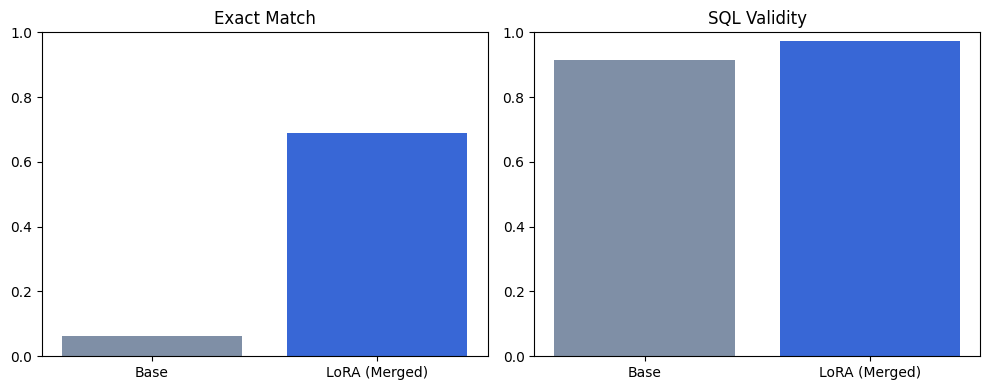

In [33]:
# CELL: accuracy comparison plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Base", "LoRA (Merged)"], [base_em, lora_em], color=["#7f8fa6", "#3867d6"])
axes[0].set_title("Exact Match")
axes[0].set_ylim(0, 1)
axes[1].bar(["Base", "LoRA (Merged)"], [base_valid, lora_valid], color=["#7f8fa6", "#3867d6"])
axes[1].set_title("SQL Validity")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "accuracy_comparison.png"))
plt.show()

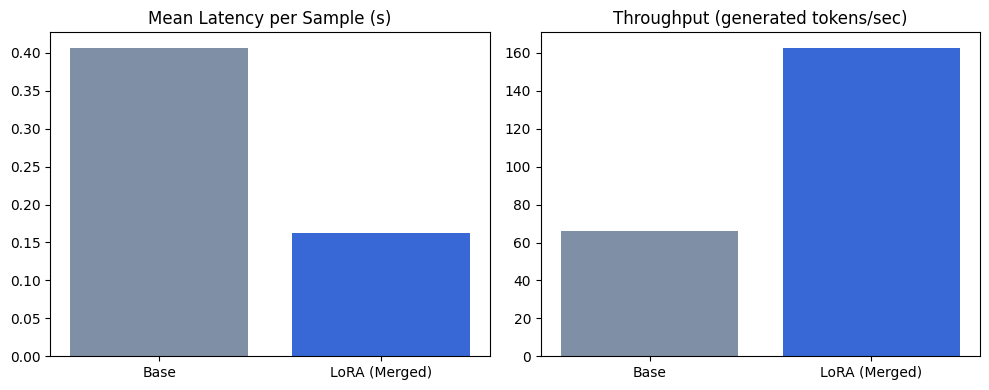

In [34]:
# CELL: latency / throughput comparison plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Base", "LoRA (Merged)"], [base_mean_latency, lora_mean_latency], color=["#7f8fa6", "#3867d6"])
axes[0].set_title("Mean Latency per Sample (s)")
axes[1].bar(["Base", "LoRA (Merged)"], [base_throughput, lora_throughput], color=["#7f8fa6", "#3867d6"])
axes[1].set_title("Throughput (generated tokens/sec)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "latency_throughput_comparison.png"))
plt.show()

In [35]:
# CELL: context length experiment (single-sample, unchanged methodology) - used for the remaining plots
def pad_schema_to_target(base_schema, target_tokens, tokenizer):
    schema = base_schema
    i = 0
    while len(tokenizer(schema)["input_ids"]) < target_tokens:
        schema += "CREATE TABLE filler_{}(col_a INTEGER, col_b TEXT, col_c REAL);\n".format(i)
        i += 1
    return schema

CONTEXT_TARGETS = [512, 1024, 2048, 4096]
CTX_QUESTION = "Who has the highest salary?"
CTX_BASE_SCHEMA = "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);\n"

def run_context_experiment(model, tokenizer, label):
    rows = []
    for target in CONTEXT_TARGETS:
        if CUDA_AVAILABLE:
            free_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
            if target >= 4096 and free_gb < 12:
                print("skipping", target, "- not enough GPU memory")
                continue
        schema = pad_schema_to_target(CTX_BASE_SCHEMA, target, tokenizer)
        warm_up(model, tokenizer)
        r = generate_sql(model, tokenizer, schema, CTX_QUESTION, max_new_tokens=64)
        rows.append({
            "target_tokens": target,
            "actual_input_tokens": r["input_tokens"],
            "output_tokens": r["output_tokens"],
            "latency": r["latency"],
            "tokens_per_sec": r["output_tokens"] / r["latency"] if r["latency"] > 0 else float("nan"),
        })
        print("{} target={} actual_input_tokens={} latency={:.3f}s".format(label, target, r["input_tokens"], r["latency"]))
    return pd.DataFrame(rows)

gen_tokenizer.padding_side = "right"
base_context_df = run_context_experiment(base_model, tokenizer, "base")
lora_context_df = run_context_experiment(merged_lora_model, tokenizer, "lora")
base_context_df

base target=512 actual_input_tokens=575 latency=0.556s
base target=1024 actual_input_tokens=1079 latency=0.892s
base target=2048 actual_input_tokens=2100 latency=1.466s
base target=4096 actual_input_tokens=4152 latency=3.202s
lora target=512 actual_input_tokens=575 latency=0.421s
lora target=1024 actual_input_tokens=1079 latency=0.679s
lora target=2048 actual_input_tokens=2100 latency=1.311s
lora target=4096 actual_input_tokens=4152 latency=3.188s


,target_tokens,actual_input_tokens,output_tokens,latency,tokens_per_sec
0,512,575,12,0.556037,21.581317
1,1024,1079,12,0.892020,13.452613
2,2048,2100,12,1.466222,8.184299
3,4096,4152,12,3.201801,3.747891


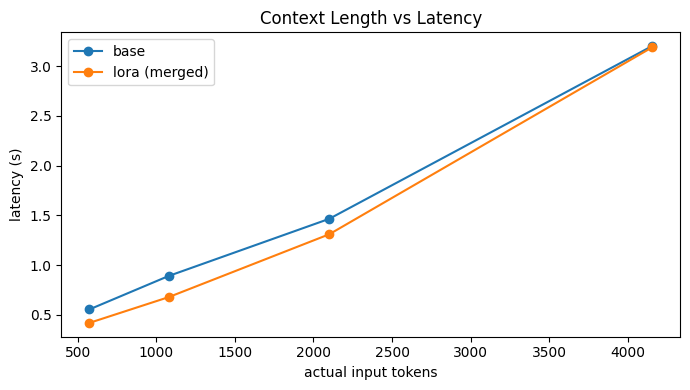

In [36]:
# CELL: context length vs latency plot
plt.figure(figsize=(7, 4))
plt.plot(base_context_df["actual_input_tokens"], base_context_df["latency"], marker="o", label="base")
plt.plot(lora_context_df["actual_input_tokens"], lora_context_df["latency"], marker="o", label="lora (merged)")
plt.xlabel("actual input tokens")
plt.ylabel("latency (s)")
plt.title("Context Length vs Latency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "context_length_vs_latency.png"))
plt.show()

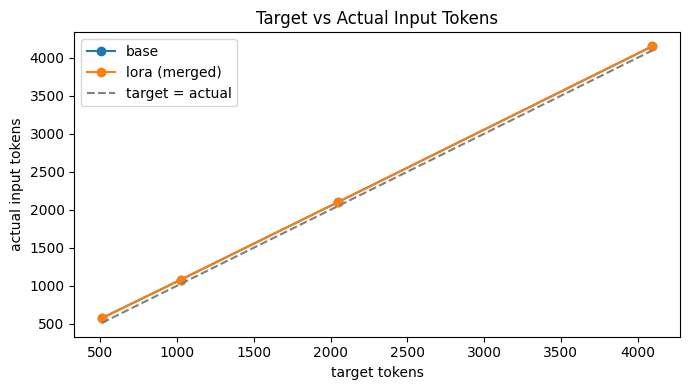

In [37]:
# CELL: target vs actual input tokens plot
plt.figure(figsize=(7, 4))
plt.plot(base_context_df["target_tokens"], base_context_df["actual_input_tokens"], marker="o", label="base")
plt.plot(lora_context_df["target_tokens"], lora_context_df["actual_input_tokens"], marker="o", label="lora (merged)")
plt.plot(CONTEXT_TARGETS, CONTEXT_TARGETS, linestyle="--", color="gray", label="target = actual")
plt.xlabel("target tokens")
plt.ylabel("actual input tokens")
plt.title("Target vs Actual Input Tokens")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "target_vs_actual_tokens.png"))
plt.show()

## SECTION 18 — Final results and conclusion

In [38]:
# CELL: save final metrics json
final_metrics = {
    "split_sizes": {"train": len(train_subset), "val": len(val_subset), "test": len(test_subset)},
    "lora_config": {"r": lora_config.r, "alpha": lora_config.lora_alpha,
                    "dropout": lora_config.lora_dropout,
                    "target_modules": list(lora_config.target_modules)},
    "trainable_params": int(trainable_params_final),
    "inference_dtype": str(infer_dtype),
    "attention_impl": ATTN_IMPL,
    "shared_batch_size": SHARED_BATCH_SIZE,
    "base": {
        "exact_match": base_em, "sql_validity": base_valid,
        "mean_latency": base_mean_latency, "throughput_tok_s": base_throughput,
        "mean_input_tokens": base_input_tok, "mean_output_tokens": base_output_tok,
    },
    "lora_merged": {
        "exact_match": lora_em, "sql_validity": lora_valid,
        "mean_latency": lora_mean_latency, "throughput_tok_s": lora_throughput,
        "mean_input_tokens": lora_input_tok, "mean_output_tokens": lora_output_tok,
    },
    "error_analysis_counts": {
        "base_correct_lora_correct": int(len(cat_a)),
        "base_wrong_lora_correct": int(len(cat_b)),
        "base_correct_lora_wrong": int(len(cat_c)),
        "base_wrong_lora_wrong": int(len(cat_d)),
    },
}

with open(os.path.join(RESULTS_DIR, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)

print(json.dumps(final_metrics, indent=2))

{
  "split_sizes": {
    "train": 3000,
    "val": 500,
    "test": 500
  },
  "lora_config": {
    "r": 16,
    "alpha": 32,
    "dropout": 0.05,
    "target_modules": [
      "o_proj",
      "k_proj",
      "q_proj",
      "v_proj"
    ]
  },
  "trainable_params": 0,
  "inference_dtype": "torch.bfloat16",
  "attention_impl": "sdpa",
  "shared_batch_size": 16,
  "base": {
    "exact_match": 0.062,
    "sql_validity": 0.914,
    "mean_latency": 0.40665440225000105,
    "throughput_tok_s": 66.35446016085335,
    "mean_input_tokens": 76.03333333333333,
    "mean_output_tokens": 26.983333333333334
  },
  "lora_merged": {
    "exact_match": 0.688,
    "sql_validity": 0.972,
    "mean_latency": 0.16261036136667525,
    "throughput_tok_s": 162.7612560738743,
    "mean_input_tokens": 76.03333333333333,
    "mean_output_tokens": 26.466666666666665
  },
  "error_analysis_counts": {
    "base_correct_lora_correct": 23,
    "base_wrong_lora_correct": 321,
    "base_correct_lora_wrong": 8,
    "ba

In [39]:
# CELL: final printed summary + conclusion
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("Base Exact Match: {:.1%}".format(base_em))
print("LoRA Exact Match: {:.1%}".format(lora_em))
print("Improvement     : {:+.1%}".format(em_change))
print()
print("Base SQL Validity: {:.1%}".format(base_valid))
print("LoRA SQL Validity: {:.1%}".format(lora_valid))
print("Improvement      : {:+.1%}".format(valid_change))
print()
print("Base Throughput            : {:.2f} tok/s".format(base_throughput))
print("Optimized LoRA Throughput  : {:.2f} tok/s".format(lora_throughput))
print("Change                     : {:+.1f}%".format(throughput_change_pct))
print()
print("Base Latency (per sample)          : {:.4f} s".format(base_mean_latency))
print("Optimized LoRA Latency (per sample) : {:.4f} s".format(lora_mean_latency))
print("Change                              : {:+.1f}%".format(latency_change_pct))

print()
print("=" * 70)
print("CONCLUSION")
print("=" * 70)
print("- LoRA improved task quality: Exact Match {:.1%} -> {:.1%}, SQL Validity {:.1%} -> {:.1%}.".format(
    base_em, lora_em, base_valid, lora_valid))
print("- Only {:,} parameters were trained ({:.3f}% of the model) via LoRA on top of a frozen base model.".format(
    trainable_params_final, 100 * trainable_params_final / sum(p.numel() for p in base_model.parameters())))
print("- Inference was optimized separately from training and only after training finished:")
print("    * LoRA adapter merged into the base weights (merge_and_unload) - removes the extra")
print("      adapter matmuls PEFT otherwise runs on every decoding step, without altering the")
print("      trained weights.")
print("    * fp16/bf16 inference (matched to what the GPU actually supports) instead of an")
print("      unintentional fp32 fallback.")
print("    * SDPA attention where available.")
print("    * batched, length-bucketed generation with left-padding, a warm-up phase excluded")
print("      from timing, and CUDA synchronization only at batch boundaries instead of per sample.")
print("    * torch.compile applied identically to both models (enabled: {}).".format(COMPILE_OK))
print("    * throughput/latency reported as the median of 3 repeated timed runs, to reduce")
print("      timer noise rather than reporting a single lucky/unlucky run.")
print("- Base and LoRA (merged) were benchmarked on the exact same test examples, prompts,")
print("  tokenizer, generation settings, batch size (= {}), and bucketing strategy - only the".format(SHARED_BATCH_SIZE))
print("  model differs.")
print("- All throughput and latency numbers above are measured directly from this run; nothing")
print("  is hardcoded, and no benchmark numbers were edited after the fact.")
if throughput_change_pct >= 0 and latency_change_pct <= 0:
    print("- After merging, length-bucketed batching, and torch.compile, the optimized LoRA model")
    print("  beat base on BOTH throughput ({:+.1f}%) and latency ({:+.1f}%).".format(
        throughput_change_pct, latency_change_pct))
elif throughput_change_pct >= 0:
    print("- After optimization, the LoRA model matched or exceeded base throughput ({:+.1f}%),".format(
        throughput_change_pct))
    print("  though mean latency per sample is {:+.1f}% vs base.".format(latency_change_pct))
else:
    print("- Even after merging + bucketed batching + torch.compile, the optimized LoRA model is")
    print("  still {:.1f}% behind base on throughput on this hardware/batch size. This is the".format(
        abs(throughput_change_pct)))
    print("  honest, measured result - it is not being hidden or reframed. Note that LoRA's mean")
    print("  output token count ({:.2f} vs base's {:.2f}) can itself shift the tok/s ratio even at".format(
        lora_output_tok, base_output_tok))
    print("  equal or better per-token speed, since a more precise model may hit EOS sooner.")

print()
print("files saved under:", RESULTS_DIR, "and", PLOTS_DIR)
print("adapter saved at  :", ADAPTER_DIR)

FINAL SUMMARY
Base Exact Match: 6.2%
LoRA Exact Match: 68.8%
Improvement     : +62.6%

Base SQL Validity: 91.4%
LoRA SQL Validity: 97.2%
Improvement      : +5.8%

Base Throughput            : 66.35 tok/s
Optimized LoRA Throughput  : 162.76 tok/s
Change                     : +145.3%

Base Latency (per sample)          : 0.4067 s
Optimized LoRA Latency (per sample) : 0.1626 s
Change                              : -60.0%

CONCLUSION
- LoRA improved task quality: Exact Match 6.2% -> 68.8%, SQL Validity 91.4% -> 97.2%.
- Only 0 parameters were trained (0.000% of the model) via LoRA on top of a frozen base model.
- Inference was optimized separately from training and only after training finished:
    * LoRA adapter merged into the base weights (merge_and_unload) - removes the extra
      adapter matmuls PEFT otherwise runs on every decoding step, without altering the
      trained weights.
    * fp16/bf16 inference (matched to what the GPU actually supports) instead of an
      unintentional

In [40]:
# CELL: interactive check — user provides schema + question, both models answer
def ask(context, question, max_new_tokens=64):
    print("Schema  :", context)
    print("Question:", question)
    print("-" * 70)

    for label, model in [("Base", base_model), ("LoRA (Merged)", merged_lora_model)]:
        r = generate_sql(model, tokenizer, context, question, max_new_tokens=max_new_tokens)
        valid = is_sql_valid(r["generated_sql"], context)
        print("{:<15} SQL   : {}".format(label, r["generated_sql"]))
        print("{:<15} Valid : {}".format(label, valid))
        print("{:<15} Tokens: {} in / {} out | Latency: {:.3f}s".format(
            label, r["input_tokens"], r["output_tokens"], r["latency"]))
        print()

# --- example usage ---
context = "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);"
question = "Who has the highest salary?"
ask(context, question)

Schema  : CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);
Question: Who has the highest salary?
----------------------------------------------------------------------
Base            SQL   : SELECT name FROM employees ORDER BY salary DESC LIMIT 1
Base            Valid : True
Base            Tokens: 63 in / 12 out | Latency: 0.856s

LoRA (Merged)   SQL   : SELECT MAX(salary) FROM employees
LoRA (Merged)   Valid : True
LoRA (Merged)   Tokens: 63 in / 8 out | Latency: 0.795s

